# Aula 14 — Valuation e DRE: da Demonstração ao Valor da Empresa
Semana 7 | 50 min | Referências: McKinney, Cap. 11 (dados financeiros e econômicos) · Jansen, Cap. 5 (portfólio e avaliação de performance)

**Caso**: *Granol & Cia Ltda.* — PME goiana do polo granoleiro (Goiânia), faturando
~R$ 12 milhões/ano em esmagamento de soja. Vamos transformar DRE e Balanço em DataFrames,
calcular indicadores, projetar 3 anos e estimar o valor da empresa pelo **fluxo de caixa
descontado (FCFF)**.

## 🎯 Objetivos de aprendizagem
Ao final desta aula, você será capaz de:

- Modelar uma **DRE** e um **Balanço Patrimonial** em DataFrames com índices de ano;
- Executar **análise vertical** (% da receita) e **horizontal** (variação ano a ano);
- Calcular os indicadores clássicos: liquidez, endividamento, margens, **ROE (DuPont)** e **ROIC**;
- Montar o **FCFF** = EBIT×(1−t) + D&A − Capex − ΔNCG e entender cada termo;
- Fazer um **valuation** por fluxo descontado com valor terminal de Gordon e testar
  a sensibilidade do resultado a WACC e crescimento perpetuo.

In [1]:
# Setup — imports e padrões visuais usados na aula
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({
    "figure.figsize": (9, 4.5),
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

def brl(x):
    """Formata um número como moeda brasileira: R$ 1.234,56."""
    return f"R$ {x:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

DATA = Path("../data/csv")  # notebook mora em semana_07/; dados em data/csv/

np.random.seed(42)  # reprodutibilidade quando houver aleatoriedade

## 1. A DRE como DataFrame

A DRE (Demonstração do Resultado do Exercício) é uma **subtração em cascata**: da receita,
tira-se o custo do que foi vendido; do que sobra (lucro bruto), tiram-se despesas; do
resultado operacional, tira-se o efeito financeiro; e o imposto leva sua fatia de 34%
(IRPJ + CSLL, alíquota combinada típica de lucro real).

Nossa empresa: *Granol & Cia Ltda.*, esmagadora de soja de Goiânia. Valores em **R$ mil**,
números sintéticos calibrados com margens plausíveis do setor (CMV ≈ 62% da receita líquida).

In [2]:
# DRE 2023-2025 (R$ mil): as contas brutas primeiro; as derivadas, a seguir
contas = pd.DataFrame(
    {
        "receita_bruta":    [11_300, 12_180, 13_050],
        "deducoes":         [   904,    974,  1_044],  # impostos s/ vendas (~8%)
        "cmv":              [ 6_446,  6_948,  7_444],  # custo da soja e do óleo (62% da receita líq.)
        "desp_adm_vendas":  [ 2_316,  2_421,  2_641],  # folha, frete, comercial
        "deprec_amort":     [   320,    350,    385],
        "res_financeiro":   [  -310,   -285,   -260],  # juros dos empréstimos
    },
    index=[2023, 2024, 2025],
)
contas

,receita_bruta,deducoes,cmv,desp_adm_vendas,deprec_amort,res_financeiro
2023,11300,904,6446,2316,320,-310
2024,12180,974,6948,2421,350,-285
2025,13050,1044,7444,2641,385,-260


In [3]:
# Derivando as linhas clássicas da DRE — cada linha da cascata em uma linha de código
dre = contas.copy()
dre["receita_liquida"] = dre["receita_bruta"] - dre["deducoes"]
dre["lucro_bruto"] = dre["receita_liquida"] - dre["cmv"]
dre["ebitda"] = dre["lucro_bruto"] - dre["desp_adm_vendas"]
dre["ebit"] = dre["ebitda"] - dre["deprec_amort"]
dre["lair"] = dre["ebit"] + dre["res_financeiro"]
dre["lucro_liquido"] = (dre["lair"] * 0.66).round(0)  # IRPJ+CSLL = 34% do LAIR
dre

,receita_bruta,deducoes,cmv,desp_adm_vendas,deprec_amort,res_financeiro,receita_liquida,lucro_bruto,ebitda,ebit,lair,lucro_liquido
2023,11300,904,6446,2316,320,-310,10396,3950,1634,1314,1004,663.0
2024,12180,974,6948,2421,350,-285,11206,4258,1837,1487,1202,793.0
2025,13050,1044,7444,2641,385,-260,12006,4562,1921,1536,1276,842.0


## 2. Análise vertical e horizontal

Duas perguntas complementares: **vertical** — quanto cada conta pesa em % da receita
(estrutura de custos: este ano é diferente de 2023?); **horizontal** — quanto cada linha
cresceu % em relação ao ano anterior (tendência: o lucro cresce mais que a receita?).
A comparação de crescimento entre linhas revela **alavancagem operacional**.

In [4]:
# Vertical: cada conta como % da receita líquida do próprio ano (axis=0 divide por coluna)
vertical = (dre[["receita_bruta", "cmv", "desp_adm_vendas", "ebitda", "lucro_liquido"]]
            .div(dre["receita_liquida"], axis=0))
vertical.round(3)

,receita_bruta,cmv,desp_adm_vendas,ebitda,lucro_liquido
2023,1.087,0.62,0.223,0.157,0.064
2024,1.087,0.62,0.216,0.164,0.071
2025,1.087,0.62,0.220,0.160,0.070


In [5]:
# Análise HORIZONTAL: variação % ano a ano — pct_change() compara cada ano com o anterior
horizontal = dre[["receita_liquida", "lucro_bruto", "ebitda", "lucro_liquido"]].pct_change() * 100
horizontal.round(1)  # 2023 fica NaN: não há ano anterior para comparar

,receita_liquida,lucro_bruto,ebitda,lucro_liquido
2023,NaN,NaN,NaN,NaN
2024,7.8,7.8,12.4,19.6
2025,7.1,7.1,4.6,6.2


## 3. O Balanço Patrimonial em DataFrame

O Balanço é uma **fotografia**: o que a empresa tem (Ativo) e como foi financiado
(Passivo + Patrimônio Líquido). A identidade contábil — Ativo = Passivo + PL — é a nossa
prova dos nove: se os números não fecham, o DataFrame está errado.

In [6]:
# Balanço simplificado (R$ mil, fechamento de cada ano)
ativo = pd.DataFrame(
    {
        "caixa":       [  850,   900,   950],
        "clientes":    [1_450, 1_600, 1_750],   # duplicatas a receber
        "estoques":    [1_700, 1_850, 2_000],   # soja em grão e óleo acabado
        "imobilizado": [4_600, 4_850, 5_100],   # prensa, silos, frota (líquido)
    },
    index=[2023, 2024, 2025],
)

passivo = pd.DataFrame(
    {
        "fornecedores":       [1_350, 1_480, 1_600],
        "divida_curto":       [  900,   850,   800],
        "divida_longo":       [1_700, 1_500, 1_300],
        "patrimonio_liquido": [4_650, 5_370, 6_100],
    },
    index=[2023, 2024, 2025],
)

# Prova dos nove: Ativo = Passivo + PL em todos os anos? (0,00 = perfeito)
(ativo.sum(axis=1) - passivo.sum(axis=1)).round(2)

2023    0
2024    0
2025    0
dtype: int64

## 4. Liquidez e endividamento

**Liquidez corrente** = Ativo Circulante ÷ Passivo Circulante: "cada R$ 1 que vence no
curto prazo, quantos eu tenho para pagar?". Abaixo de 1 é sinal amarelo. Já
**Dívida/EBITDA** mede quantos anos de geração operacional seriam precisos para quitar
a dívida — a métrica que bancos usam em covenants.

In [7]:
# Indicadores de liquidez e endividamento (Séries vetorizadas, sem laços)
ativo_circulante = ativo[["caixa", "clientes", "estoques"]].sum(axis=1)
passivo_circulante = passivo["fornecedores"] + passivo["divida_curto"]

indicadores = pd.DataFrame({
    "liquidez_corrente": ativo_circulante / passivo_circulante,
    "liquidez_seca": (ativo_circulante - ativo["estoques"]) / passivo_circulante,
    "divida_total": passivo["divida_curto"] + passivo["divida_longo"],
})
indicadores["divida_sobre_ebitda"] = indicadores["divida_total"] / dre["ebitda"]
indicadores.round(2)

,liquidez_corrente,liquidez_seca,divida_total,divida_sobre_ebitda
2023,1.78,1.02,2600,1.59
2024,1.87,1.07,2350,1.28
2025,1.96,1.12,2100,1.09


## 5. Margens: a radiografia da rentabilidade

Cada margem responde uma pergunta: a **bruta** fala da eficiência de produção (soja cara
aperta); a **EBITDA** aproxima a geração de caixa operacional; a **líquida** é o que fica
de cada R$ 1 vendido depois de todo mundo ser pago.

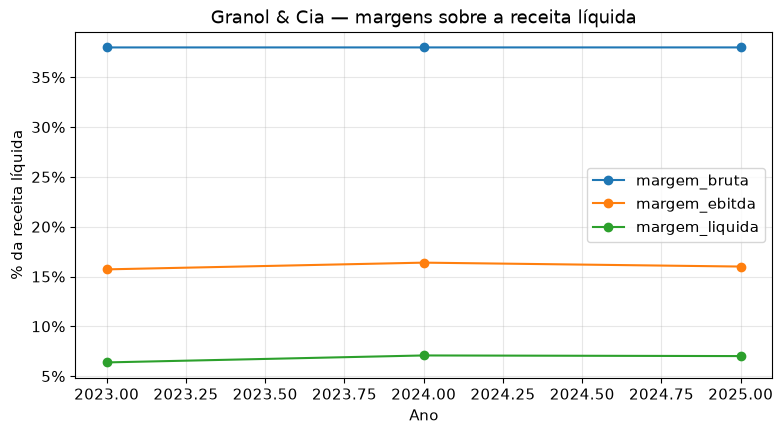

,margem_bruta,margem_ebitda,margem_liquida
2023,38.0,15.7,6.4
2024,38.0,16.4,7.1
2025,38.0,16.0,7.0


In [8]:
# Margens em % da receita líquida + gráfico de tendência
margens = pd.DataFrame({
    "margem_bruta":   dre["lucro_bruto"] / dre["receita_liquida"],
    "margem_ebitda":  dre["ebitda"] / dre["receita_liquida"],
    "margem_liquida": dre["lucro_liquido"] / dre["receita_liquida"],
}) * 100

fig, ax = plt.subplots()
margens.plot(marker="o", ax=ax)
ax.set_title("Granol & Cia — margens sobre a receita líquida")
ax.set_xlabel("Ano")
ax.set_ylabel("% da receita líquida")
ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.0f}%")
plt.show()
margens.round(1)

## 6. Rentabilidade do capital: ROE (DuPont) e ROIC

O **ROE** (retorno sobre o patrimônio líquido) é o indicador favorito do sócio — e a
**decomposição de DuPont** o explica em três alavancas:

$$ROE = \underbrace{\frac{Lucro}{Receita}}_{\text{margem}} \times
\underbrace{\frac{Receita}{Ativo}}_{\text{giro}} \times
\underbrace{\frac{Ativo}{PL}}_{\text{alavancagem}}$$

O **ROIC** (retorno sobre o capital investido) troca o lucro contábil pelo **NOPAT**
(EBIT pós-impostos) e o PL pelo **capital investido** (dívida + PL): é neutro ao
financiamento, o que permite comparar empresas com endividamentos diferentes.

In [9]:
# Decomposição de DuPont: as três alavancas do ROE lado a lado
dupont = pd.DataFrame({
    "margem_liquida":  dre["lucro_liquido"] / dre["receita_liquida"],
    "giro_ativo":      dre["receita_liquida"] / ativo.sum(axis=1),
    "mult_alavancagem": ativo.sum(axis=1) / passivo["patrimonio_liquido"],
})
dupont["roe"] = dre["lucro_liquido"] / passivo["patrimonio_liquido"]
dupont["roe_via_dupont"] = (dupont["margem_liquida"] * dupont["giro_ativo"]
                            * dupont["mult_alavancagem"])  # prova: bate com ROE direto
dupont.round(3)

,margem_liquida,giro_ativo,mult_alavancagem,roe,roe_via_dupont
2023,0.064,1.209,1.849,0.143,0.143
2024,0.071,1.218,1.713,0.148,0.148
2025,0.070,1.225,1.607,0.138,0.138


In [10]:
# ROIC: NOPAT sobre capital investido (dívida + PL) — comparável entre estruturas distintas
nopat = dre["ebit"] * (1 - 0.34)
capital_investido = passivo["divida_curto"] + passivo["divida_longo"] + passivo["patrimonio_liquido"]

roic = pd.DataFrame({
    "nopat": nopat,
    "capital_investido": capital_investido,
    "roic": nopat / capital_investido,
})
roic.round(3)

,nopat,capital_investido,roic
2023,867.24,7250,0.120
2024,981.42,7720,0.127
2025,1013.76,8200,0.124


## 7. Fluxo de caixa livre à firma (FCFF)

O investidor não compra lucro contábil — compra **caixa**. O FCFF pergunta: quanto a
operação gera depois de impostos, reinvestimento e giro?

$$FCFF = EBIT \times (1 - t) + D\&A - Capex - \Delta NCG$$

- `+ D&A`: despesa que não sai de caixa (o dinheiro já foi gasto no passado);
- `− Capex`: investimento para manter/crescer a operação;
- `− ΔNCG`: o que fica preso no giro (clientes + estoques − fornecedores). Soja em estoque
  e prazo dado ao cliente são caixa que ainda não voltou.

In [11]:
# NCG, Capex e FCFF por ano (2023 fica NaN: dif() precisa de um ano anterior)
ncg = ativo["clientes"] + ativo["estoques"] - passivo["fornecedores"]   # necessidade de capital de giro
delta_ncg = ncg.diff()
capex = ativo["imobilizado"].diff() + dre["deprec_amort"]               # reposição + crescimento

fcff = pd.DataFrame({
    "ebit_pos_imposto": (dre["ebit"] * (1 - 0.34)).round(0),
    "deprec_amort": dre["deprec_amort"],
    "capex": capex,
    "delta_ncg": delta_ncg,
})
fcff["fcff"] = (fcff["ebit_pos_imposto"] + fcff["deprec_amort"]
                - fcff["capex"] - fcff["delta_ncg"]).round(0)
fcff.round(0)

,ebit_pos_imposto,deprec_amort,capex,delta_ncg,fcff
2023,867.0,320,NaN,NaN,NaN
2024,981.0,350,600.0,170.0,561.0
2025,1014.0,385,635.0,180.0,584.0


## 8. Valuation: trazer o futuro a valor presente

O valor da empresa é a soma dos FCFF futuros descontados a uma taxa que remunera o risco.
A taxa (**WACC**) pondera o custo do dinheiro próprio e o emprestado:

$$WACC = w_E \cdot k_E + w_D \cdot k_D (1 - t), \qquad k_E = r_f + \beta \cdot ERP$$

Números de setembro/2026: Selic **13,9% a.a.** como taxa livre de risco, prêmio de risco
de mercado **6,0%**, beta **0,9** (PME menos volátil que o Ibovespa), custo da dívida
**12% a.a.**, estrutura **75% equity / 25% dívida**.

In [12]:
# Custo de capital: CAPM para o equity, WACC ponderando as duas fontes
rf = 0.139          # Selic set/2026 (BCB) — proxy do ativo sem risco
erp = 0.06          # prêmio de risco do mercado acionário brasileiro
beta = 0.90         # risco da PME vs mercado
ke = rf + beta * erp

kd = 0.12           # custo da dívida pré-impostos (banco rural, garantia de safra)
peso_e, peso_d = 0.75, 0.25

wacc = peso_e * ke + peso_d * kd * (1 - 0.34)
print(f"Ke = {ke:.2%} | Kd líquida = {kd * (1 - 0.34):.2%} | WACC = {wacc:.2%}")

Ke = 19.30% | Kd líquida = 7.92% | WACC = 16.45%


In [13]:
# Projeção 2026-2028: receita +9% a.a. (demanda de óleo/ração), margens de 2025 estáveis
g_rec = 0.09
proj = pd.DataFrame(index=[2026, 2027, 2028])
proj["receita_liquida"] = dre["receita_liquida"].iloc[-1] * (1 + g_rec) ** np.arange(1, 4)
proj["ebitda"] = proj["receita_liquida"] * 0.16        # margem EBITDA de 2025
proj["deprec_amort"] = proj["receita_liquida"] * 0.032
proj["ebit"] = proj["ebitda"] - proj["deprec_amort"]

# Giro e investimento acompanham a receita: NCG cresce 9%; Capex = 1,15× D&A (crescimento)
proj["ncg"] = ncg.iloc[-1] * (1 + g_rec) ** np.arange(1, 4)
proj["delta_ncg"] = proj["ncg"].diff().fillna(proj["ncg"].iloc[0] - ncg.iloc[-1])
proj["capex"] = proj["deprec_amort"] * 1.15
proj["fcff"] = (proj["ebit"] * (1 - 0.34) + proj["deprec_amort"]
                - proj["capex"] - proj["delta_ncg"])
proj.round(0)

,receita_liquida,ebitda,deprec_amort,ebit,ncg,delta_ncg,capex,fcff
2026,13087.0,2094.0,419.0,1675.0,2344.0,194.0,482.0,849.0
2027,14264.0,2282.0,456.0,1826.0,2554.0,211.0,525.0,926.0
2028,15548.0,2488.0,498.0,1990.0,2784.0,230.0,572.0,1009.0


In [14]:
# Valuation: VP dos FCFF + valor terminal de Gordon; descontando a dívida líquida
t = np.arange(1, 4)
fcff_proj = proj["fcff"].values
pv_fcff = (fcff_proj / (1 + wacc) ** t).sum()

g = 0.03  # crescimento perpetuo prudente — abaixo do crescimento nominal projetado
tv = fcff_proj[-1] * (1 + g) / (wacc - g)          # Gordon: FCFF seguinte / (WACC − g)
pv_tv = tv / (1 + wacc) ** 3

valor_empresa = pv_fcff + pv_tv
divida_liquida = (passivo["divida_curto"].iloc[-1] + passivo["divida_longo"].iloc[-1]
                  - ativo["caixa"].iloc[-1])
valor_equity = valor_empresa - divida_liquida

for rotulo, val in [("VP dos FCFF 2026-28", pv_fcff), ("VP do valor terminal", pv_tv),
                    ("Valor da empresa (EV)", valor_empresa), ("(−) dívida líquida", divida_liquida),
                    ("Valor do equity", valor_equity)]:
    print(f"{rotulo:22s}: R$ {val / 1000:,.2f} mi".replace(",", "X").replace(".", ",").replace("X", "."))

VP dos FCFF 2026-28   : R$ 2,05 mi
VP do valor terminal  : R$ 4,89 mi
Valor da empresa (EV) : R$ 6,94 mi
(−) dívida líquida    : R$ 1,15 mi
Valor do equity       : R$ 5,79 mi


In [15]:
# Sensibilidade: o valuation é uma estimativa, não um número — teste WACC × g
waccs = [0.15, wacc, 0.18]
gs = [0.02, 0.03, 0.04]
sens = pd.DataFrame(index=[f"WACC {w:.1%}" for w in waccs],
                    columns=[f"g = {g:.0%}" for g in gs], dtype=float)
for w in waccs:
    for g in gs:
        vp = (fcff_proj / (1 + w) ** t).sum()
        tv_g = fcff_proj[-1] * (1 + g) / (w - g)
        sens.loc[f"WACC {w:.1%}", f"g = {g:.0%}"] = (vp + tv_g / (1 + w) ** 3) / 1000
sens.round(2)  # valores da empresa em R$ milhões

,g = 2%,g = 3%,g = 4%
WACC 15.0%,7.31,7.80,8.37
WACC 16.5%,6.56,6.94,7.39
WACC 18.0%,5.91,6.22,6.56


## 📝 Exercícios

Mesmo caso (*Granol & Cia*), DataFrames `dre`, `ativo`, `passivo` e `proj` já na memória.

**EXERCÍCIO 1 — A tendência da EBITDA.** Calcule a margem EBITDA dos três anos
(2023-2025). Ela sobe, cai ou fica estável? Em uma frase: o que isso sugere sobre o
controle de custos da Granol?

In [16]:
# EXERCÍCIO 1 — seu código aqui


In [17]:
# SOLUÇÃO 1 — divisão de Series alinhadas por índice (ano)
margem_ebitda = dre["ebitda"] / dre["receita_liquida"] * 100
margem_ebitda.round(1)
# Estável em torno de 16%: os custos crescem no mesmo ritmo da receita — gestão de
# margem madura, sem alavancagem operacional agressiva.

2023    15.7
2024    16.4
2025    16.0
dtype: float64

**EXERCÍCIO 2 — Liquidez seca.** A liquidez corrente conta estoque como dinheiro. A
**liquidez seca** exclui estoque — mais honesta quando a soja pode não virar caixa rápido.
Calcule `(AC − estoques) / PC` para os três anos e compare com a corrente.

In [18]:
# EXERCÍCIO 2 — seu código aqui


In [19]:
# SOLUÇÃO 2 — mesmo numerador da seção 4, menos o estoque
liq_seca = (ativo_circulante - ativo["estoques"]) / passivo_circulante
comparacao = pd.DataFrame({"liquidez_corrente": ativo_circulante / passivo_circulante,
                           "liquidez_seca": liq_seca})
comparacao.round(2)
# A seca é bem menor: boa parte do AC é estoque de soja — liquidez depende de vendê-la.

,liquidez_corrente,liquidez_seca
2023,1.78,1.02
2024,1.87,1.07
2025,1.96,1.12


**EXERCÍCIO 3 — DuPont de 2024.** Decomponha o ROE de 2024 nas três alavancas
(margem × giro × alavancagem) e confirme que o produto bate com o ROE direto
(lucro ÷ PL). Qual alavanca é a maior?

In [20]:
# EXERCÍCIO 3 — seu código aqui


In [21]:
# SOLUÇÃO 3 — mesmas fórmulas da seção 6, filtrando o ano de 2024
m = dre.loc[2024, "lucro_liquido"] / dre.loc[2024, "receita_liquida"]
giro = dre.loc[2024, "receita_liquida"] / ativo.loc[2024].sum()
alav = ativo.loc[2024].sum() / passivo.loc[2024, "patrimonio_liquido"]
print(f"Margem = {m:.3f} × Giro = {giro:.3f} × Alavancagem = {alav:.3f} → ROE = {m * giro * alav:.3f}")
print(f"ROE direto: {dre.loc[2024, 'lucro_liquido'] / passivo.loc[2024, 'patrimonio_liquido']:.3f}")

Margem = 0.071 × Giro = 1.218 × Alavancagem = 1.713 → ROE = 0.148
ROE direto: 0.148


**EXERCÍCIO 4 — O valor é sensível ao crescimento perpetuo.** Refaça o valuation com
`g = 2%` (cenário pessimista) e compare o novo valor da empresa com o da aula (g = 3%).
Em %, quanto cai o valor com apenas 1 p.p. a menos de crescimento perpetuo?

In [22]:
# EXERCÍCIO 4 — seu código aqui


In [23]:
# SOLUÇÃO 4 — mesma mecânica da seção 8, trocando apenas g
g_pess = 0.02
tv_pess = fcff_proj[-1] * (1 + g_pess) / (wacc - g_pess)
ev_pess = pv_fcff + tv_pess / (1 + wacc) ** 3
for rotulo, val in [("EV com g = 3%", valor_empresa), ("EV com g = 2%", ev_pess)]:
    print(f"{rotulo}: R$ {val / 1000:,.2f} mi".replace(",", "X").replace(".", ",").replace("X", "."))
print(f"Queda: {(ev_pess / valor_empresa - 1):.1%}")
# O valor terminal concentra a maior parte do EV — cada ponto de g muda o resultado bastante.

EV com g = 3%: R$ 6,94 mi
EV com g = 2%: R$ 6,56 mi
Queda: -5.5%


## 📌 Resumo & para casa

- **DRE e Balanço são tabelas**: em pandas, a cascata do resultado vira linhas derivadas e
  a identidade contábil vira uma subtração vetorial de conferência.
- **Vertical** (estrutura de custos) e **horizontal** (tendência) respondem perguntas
  diferentes — juntas contam a história da empresa.
- **DuPont** decompõe ROE em margem × giro × alavancagem; **ROIC** compara operações
  independente de como foram financiadas.
- **FCFF** = EBIT×(1−t) + D&A − Capex − ΔNCG: o caixa que sobra para os donos do capital.
- **Valuation** = VP dos fluxos + valor terminal de Gordon; o resultado é hipersensível a
  WACC e g — por isso a tabela de sensibilidade é obrigatória em relatório sério.
- Números de referência usados: Selic 13,9% a.a. (set/2026), IRPJ+CSLL 34%, SM R$ 1.518 (2026).

**Para casa**: pegue a DRE de uma empresa aberta do agronegócio (Rio Verde Agro, por exemplo)
no site de RI e refaça a análise vertical de um ano. Traga na próxima aula.

**Referências (KB)**:
- `kb/01_mckinney_python_for_data_analysis/13_chapter-11-financial-and-economic-data-applications.md` — dados financeiros e econômicos em pandas
- `kb/03_jansen_ml_for_algorithmic_trading/11_chapter-5-portfolio-optimization-and-performance-evaluation.md` — retornos, risco e métricas de desempenho